# Imports

In [1]:
import os
import sys

import numpy as np
import torch
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader



In [2]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
lenet_model = LeNet(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
epoch = load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)
# load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(475, date="20251201")}', device)


[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


# Corruptions

In [3]:
corruptions = {
    'Original': lambda x: x,
    'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'Default Blur': lambda x: gaussian_blur(x, kernel_size=5),
    'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

# Тест модели на EMNIST (out-of-distribution)

In [5]:
emnist_test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset='EMNIST'
)[2]  # Получаем только тестовый загрузчик

In [ ]:
test_accuracy = evaluate(lenet_model, emnist_test_loader, device=config.device)

Random batch index: 882, image index: 7


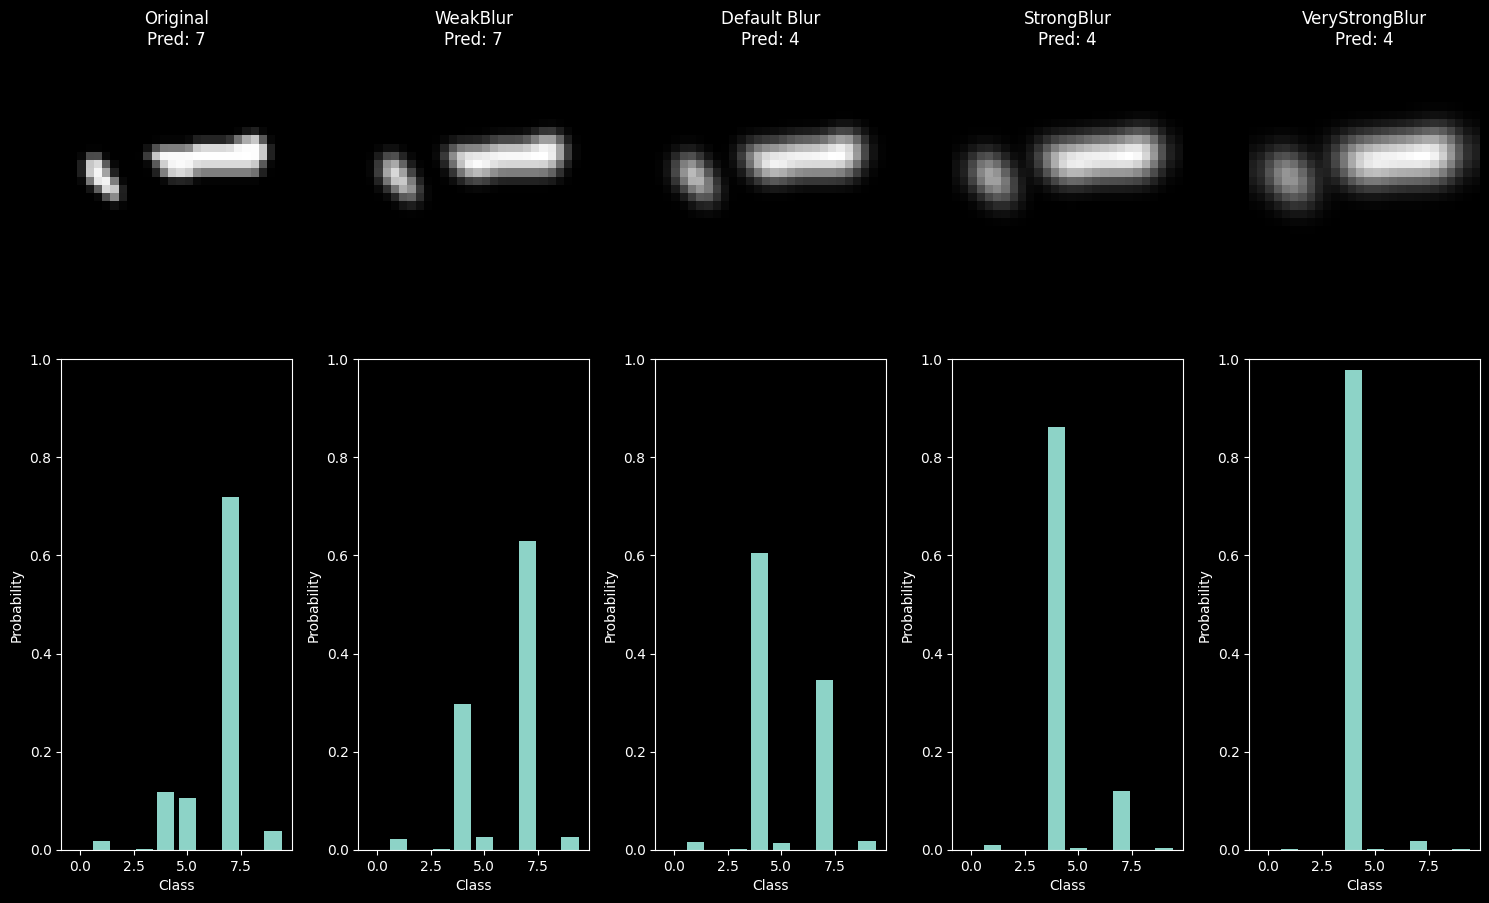

In [20]:
import random

rand_batch_idx = random.randint(0, len(emnist_test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(emnist_test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=tuple([i for i in range(10, 0, 2)]), T=10)

# Вычисление точности с гауссовским размытием

In [5]:
from torchvision.transforms import GaussianBlur

_, _, blurred_test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    extra_transforms=[
        GaussianBlur(kernel_size=9)
    ]
)


Accuracy: 98.85%
Gaussian Blur k=3:
Accuracy: 98.55%
Gaussian Blur k=5:
Accuracy: 96.68%
Gaussian Blur k=7:
Accuracy: 93.48%
Gaussian Blur k=9:
Accuracy: 92.84%


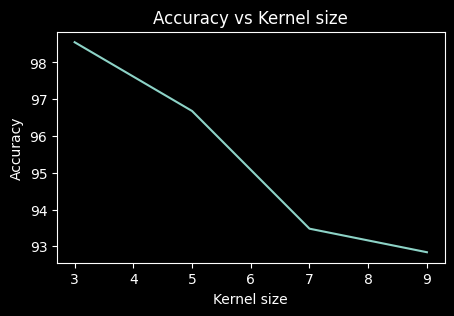

In [8]:
original_test_accuracy = evaluate(lenet_model, test_loader, device=config.device)

kernel_sizes = [3, 5, 7, 9]
accuracies = []

for kernel_size in kernel_sizes:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[
            GaussianBlur(kernel_size=kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    print(f"Gaussian Blur k={kernel_size}:")
    test_accuracy = evaluate(lenet_model, blurred_test_loader, device=config.device)
    accuracies.append(test_accuracy)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(kernel_sizes, accuracies)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Kernel size")
plt.show()

# Распределение неопределенностей разных классов на разных искажениях

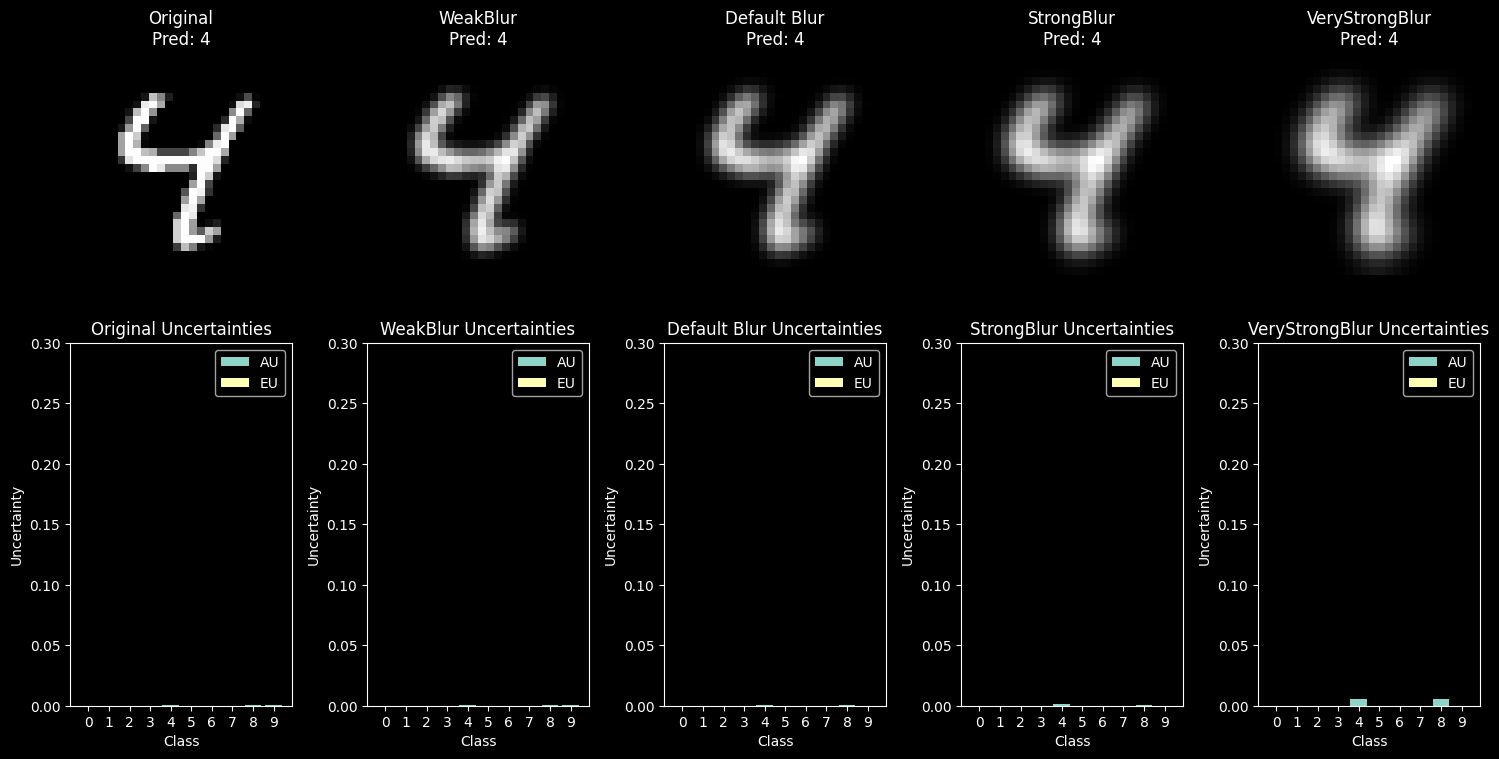

In [4]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

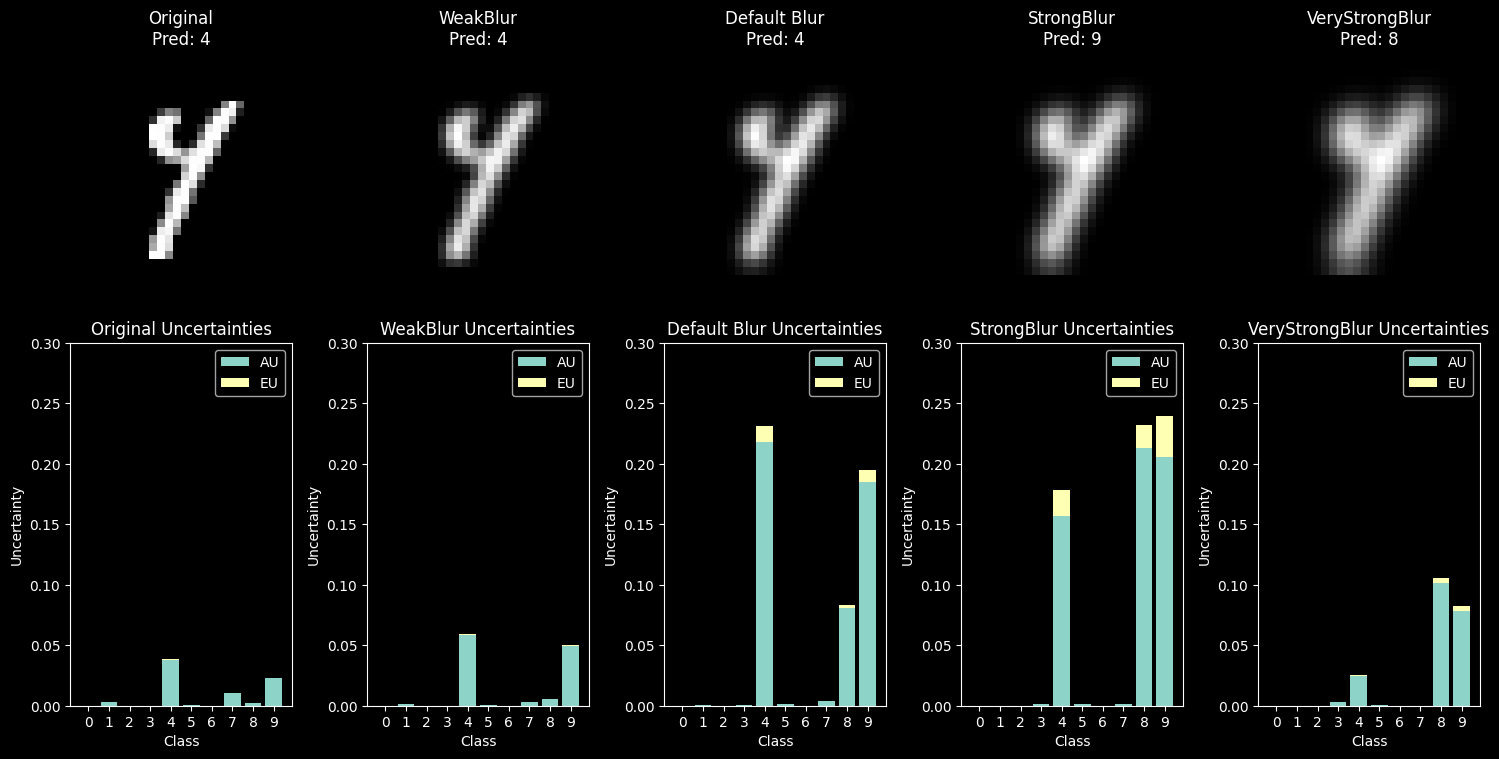

In [29]:
img, label = get_img_from_loader(test_loader, batch_idx=116, img_idx=10, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)


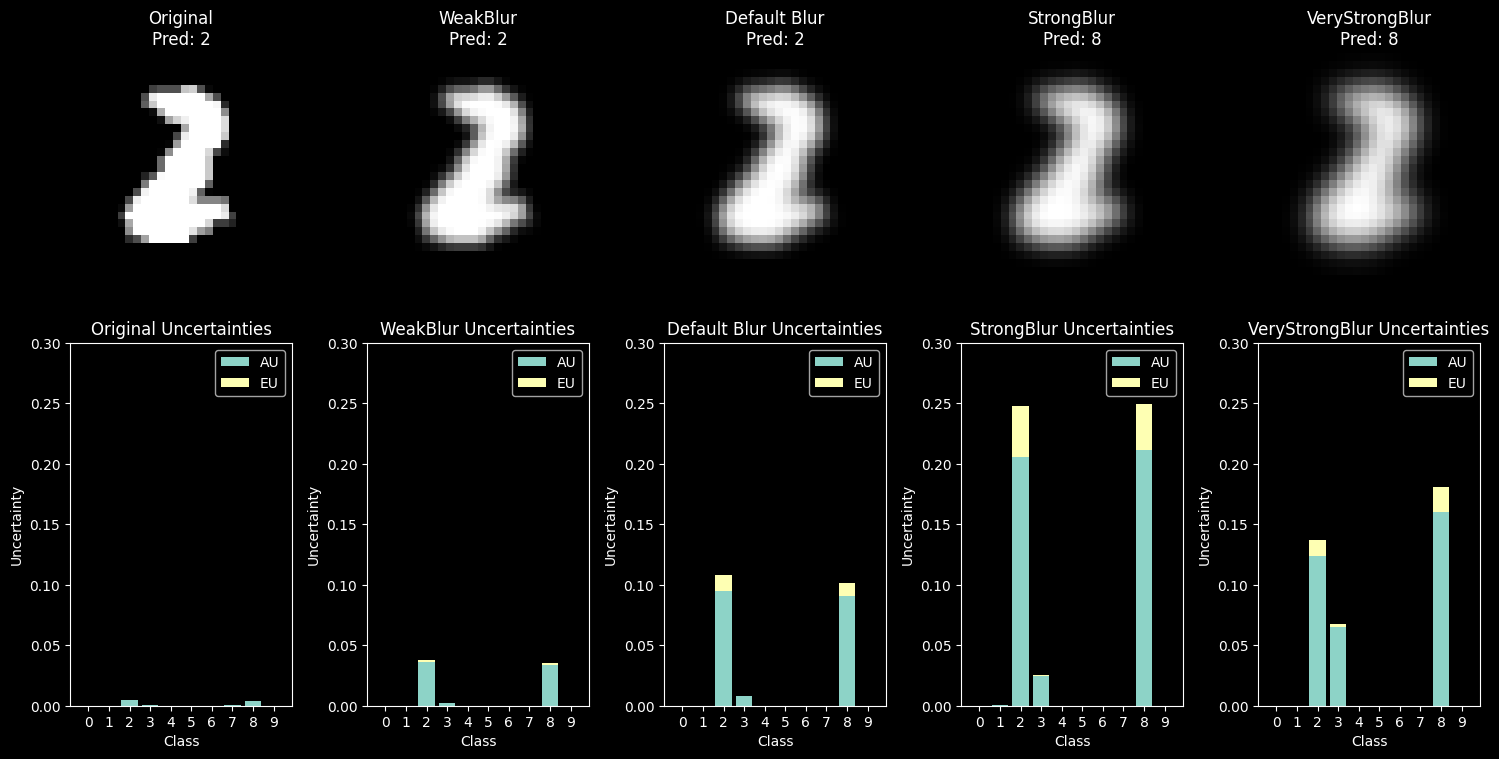

In [30]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)


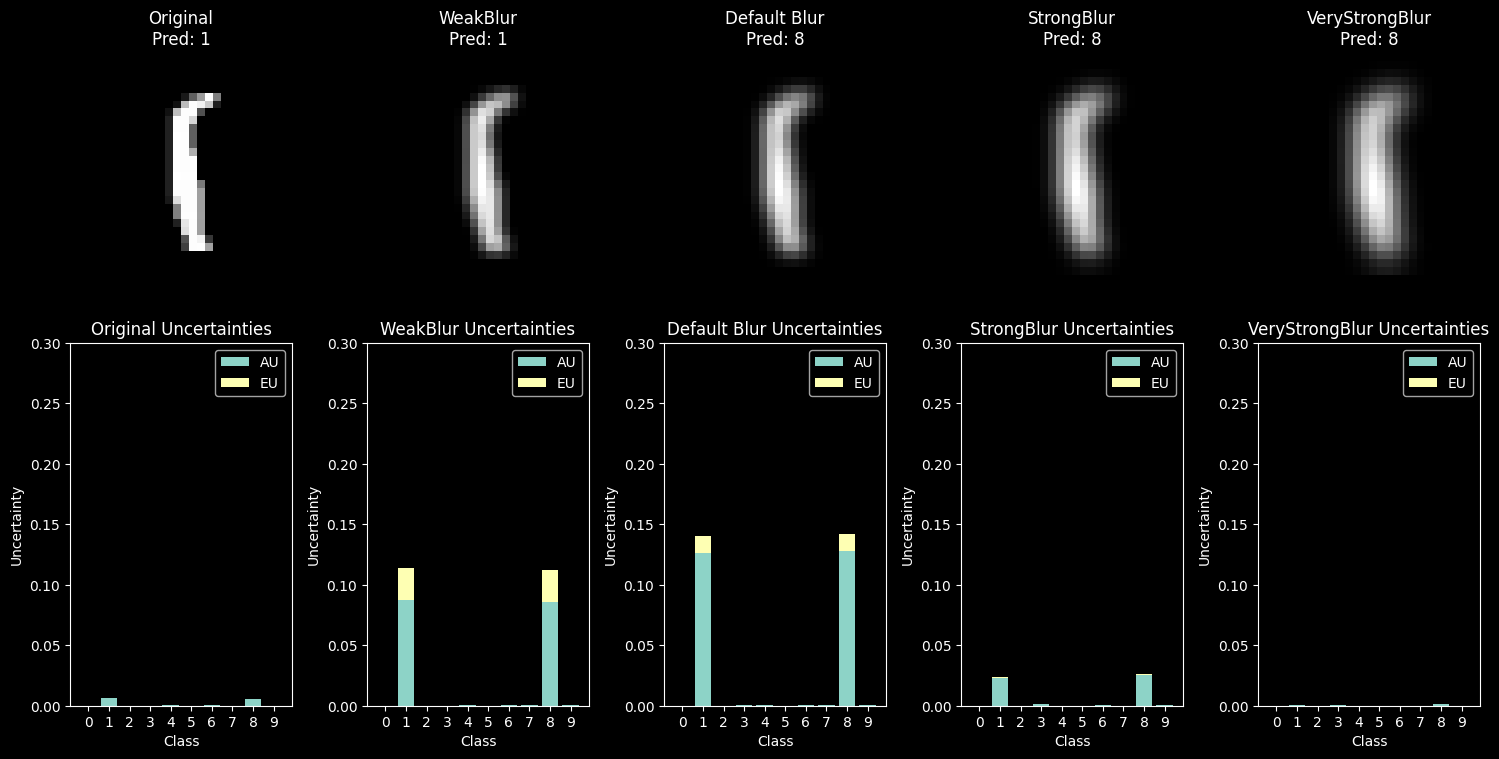

In [31]:
img, label = get_img_from_loader(test_loader, batch_idx=29, img_idx=3, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

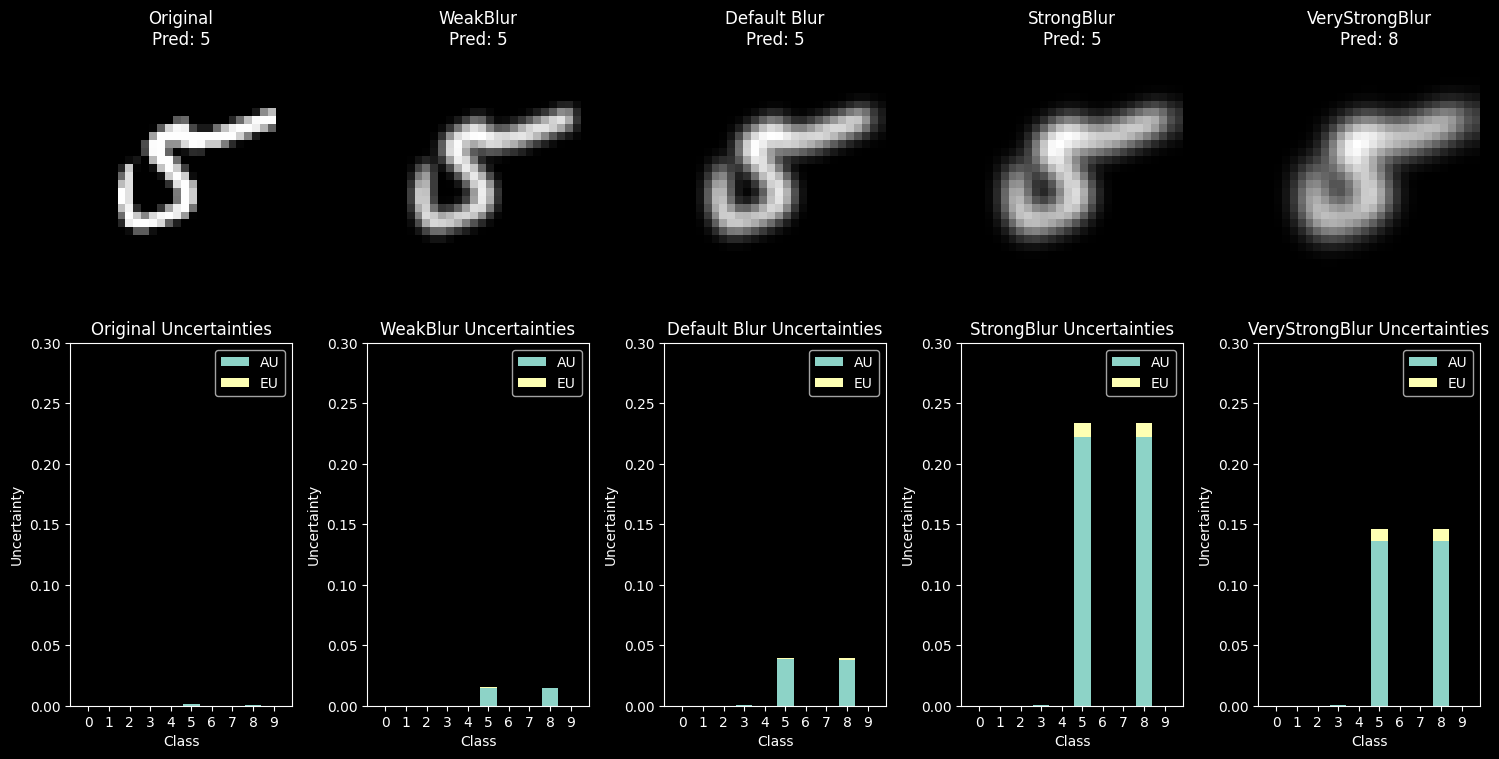

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=592, img_idx=11, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

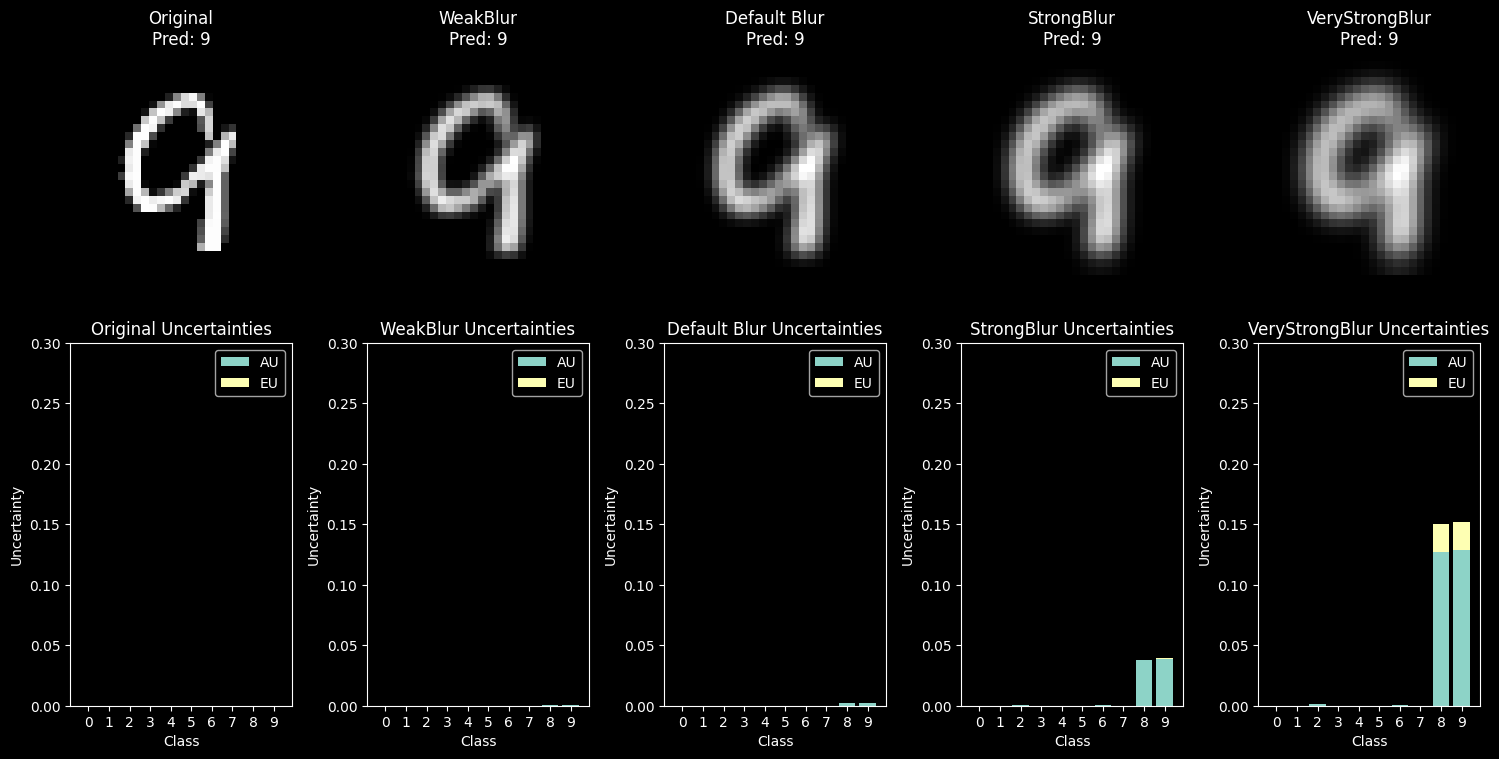

In [15]:
img, label = get_img_from_loader(test_loader, batch_idx=243, img_idx=2, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

Random batch index: 644, image index: 11


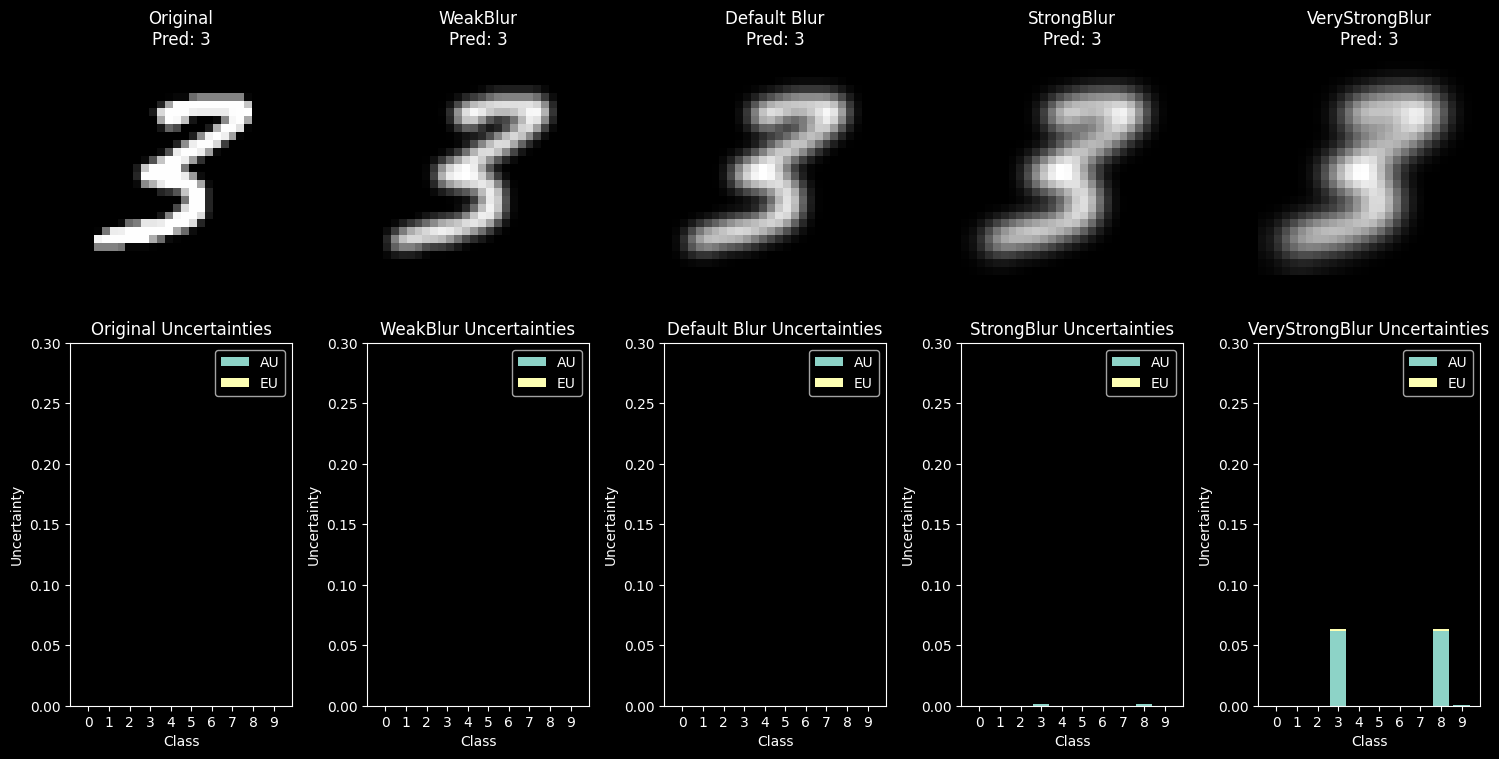

In [18]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

# Тестирование неопределенности на разных искажениях

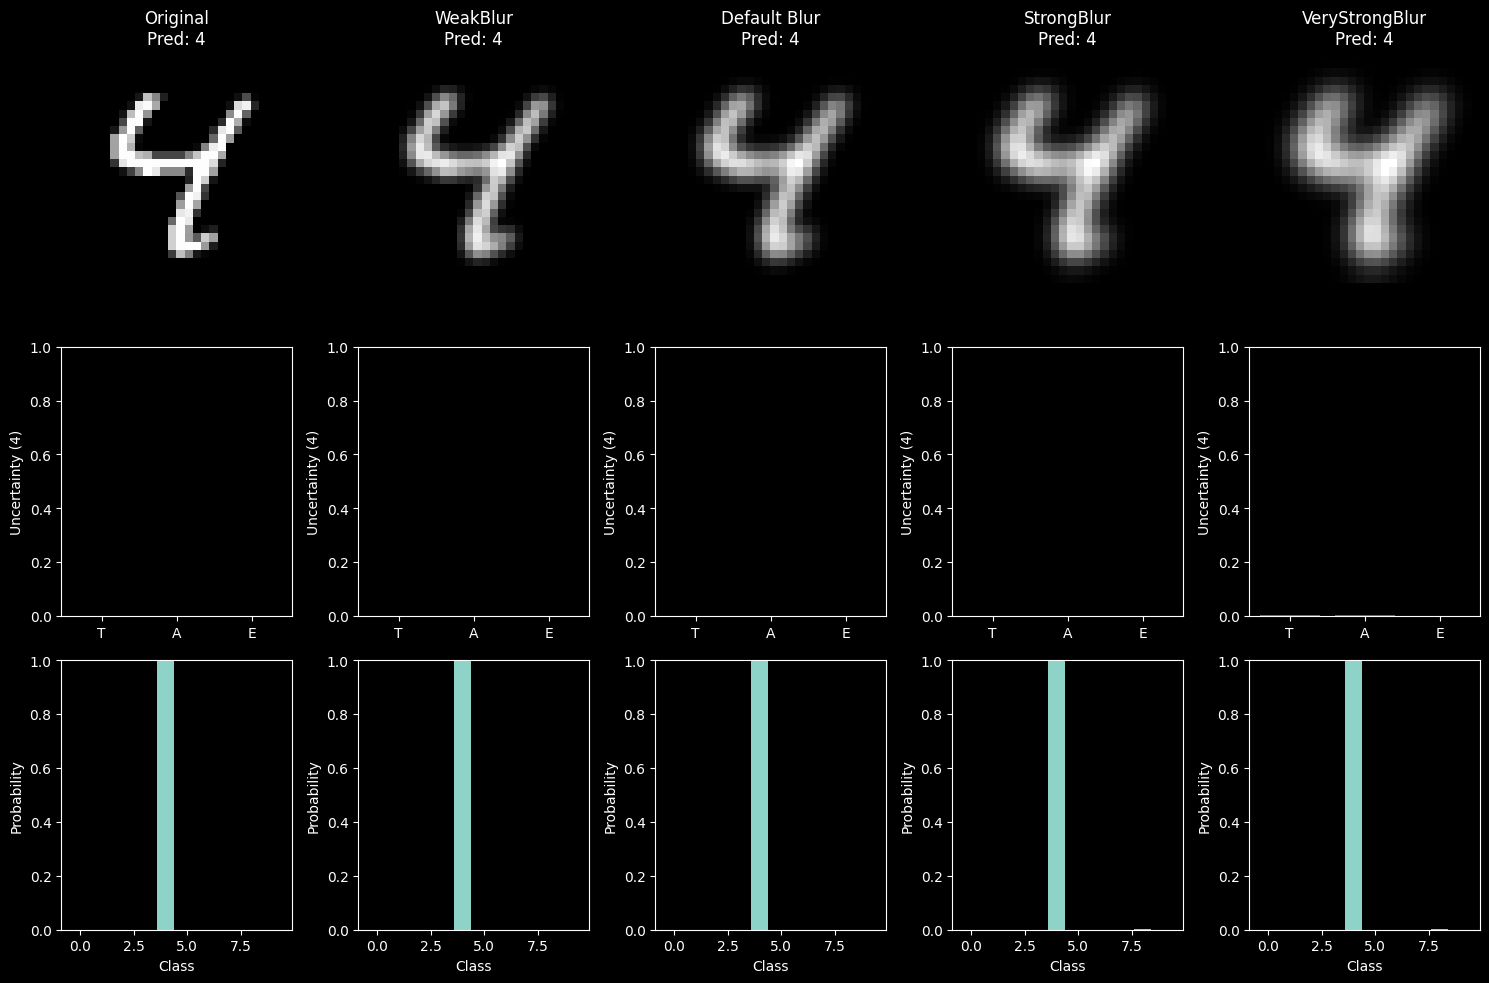

In [4]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

Random batch index: 265, image index: 6


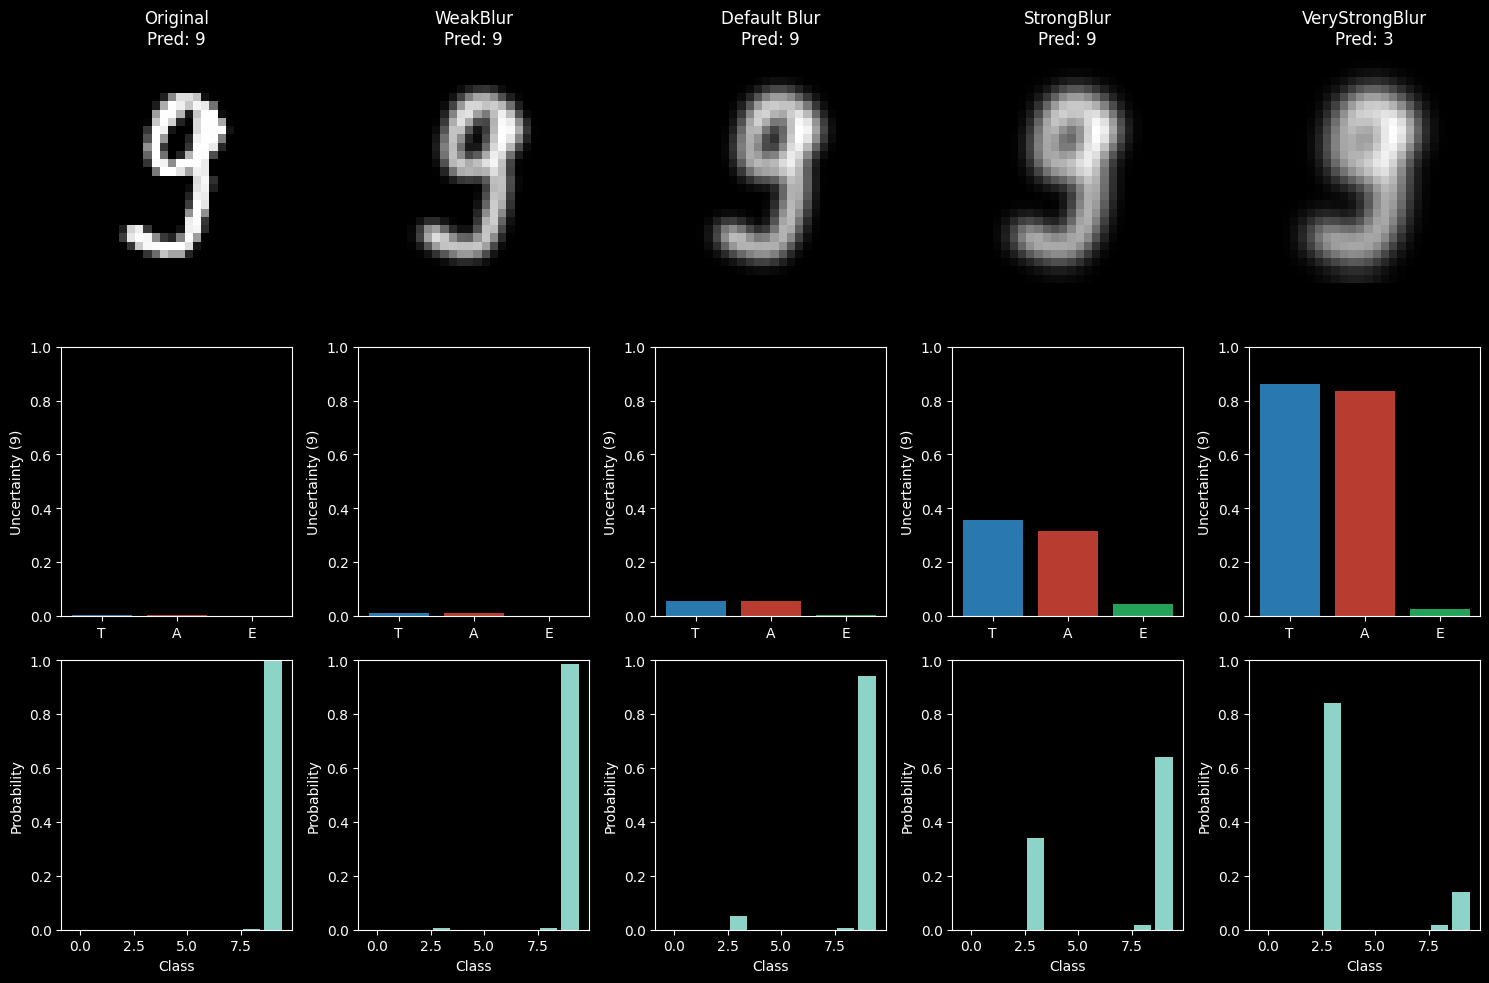

In [85]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

In [69]:
from matplotlib import pyplot as plt
from utils.uncertainty import mc_predict, quantify_uncertainties
from utils.corruptions import gaussian_blur

def corruptions_and_uncertainties_plot(model, img, label, corruptions: dict = None, T=5):
    """Зависимость алеаторной неопределенности от типа и степени искажения изображения."""

    assert corruptions is not None

    # Словарь: {class_label: {corruption_name: uncertainty_value}}
    data = {
        'true': dict(),
        'pred': dict()
    }

    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img).unsqueeze(0)
        mc_preds = mc_predict(model, corrupted, mc_samples=T)
        mean_probs = mc_preds.mean(dim=0).squeeze(0)
        pred, (_, alea, _) = quantify_uncertainties(mc_preds)

        # Для истинного класса
        true_prob = mean_probs[label].item()
        true_alea = alea[0, label, label].item()
        data['true'][name] = true_alea / true_prob

        # Для предсказанного класса
        pred_prob = mean_probs[pred].item()
        pred_alea = alea[0, pred, pred].item()
        data['pred'][name] = pred_alea / pred_prob

    # Визуализация
    fig, axes = plt.subplots(1, 2)
    # Изображение
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title(f'Number {label}')
    axes[0].axis('off')

    ax = axes[1]
    corruption_names = list(corruptions.keys())

    true_values = [data['true'][name] for name in corruption_names]
    pred_values = [data['pred'][name] for name in corruption_names]

    ax.plot(corruption_names, true_values, marker='o', label=f'True')
    ax.plot(corruption_names, pred_values, marker='s', label=f'Pred')

    ax.set_ylabel('Aleatoric Uncertainty')
    ax.set_xlabel('Corruption Type')
    ax.set_title('Uncertainty: True vs Predicted Class')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

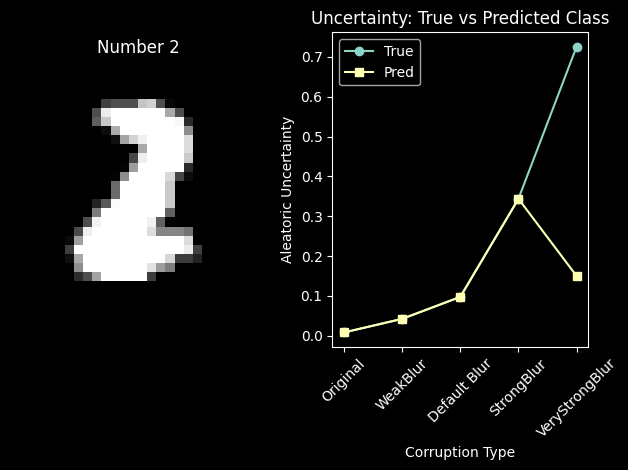

In [73]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_and_uncertainties_plot(lenet_model, img, label, corruptions, T=10)

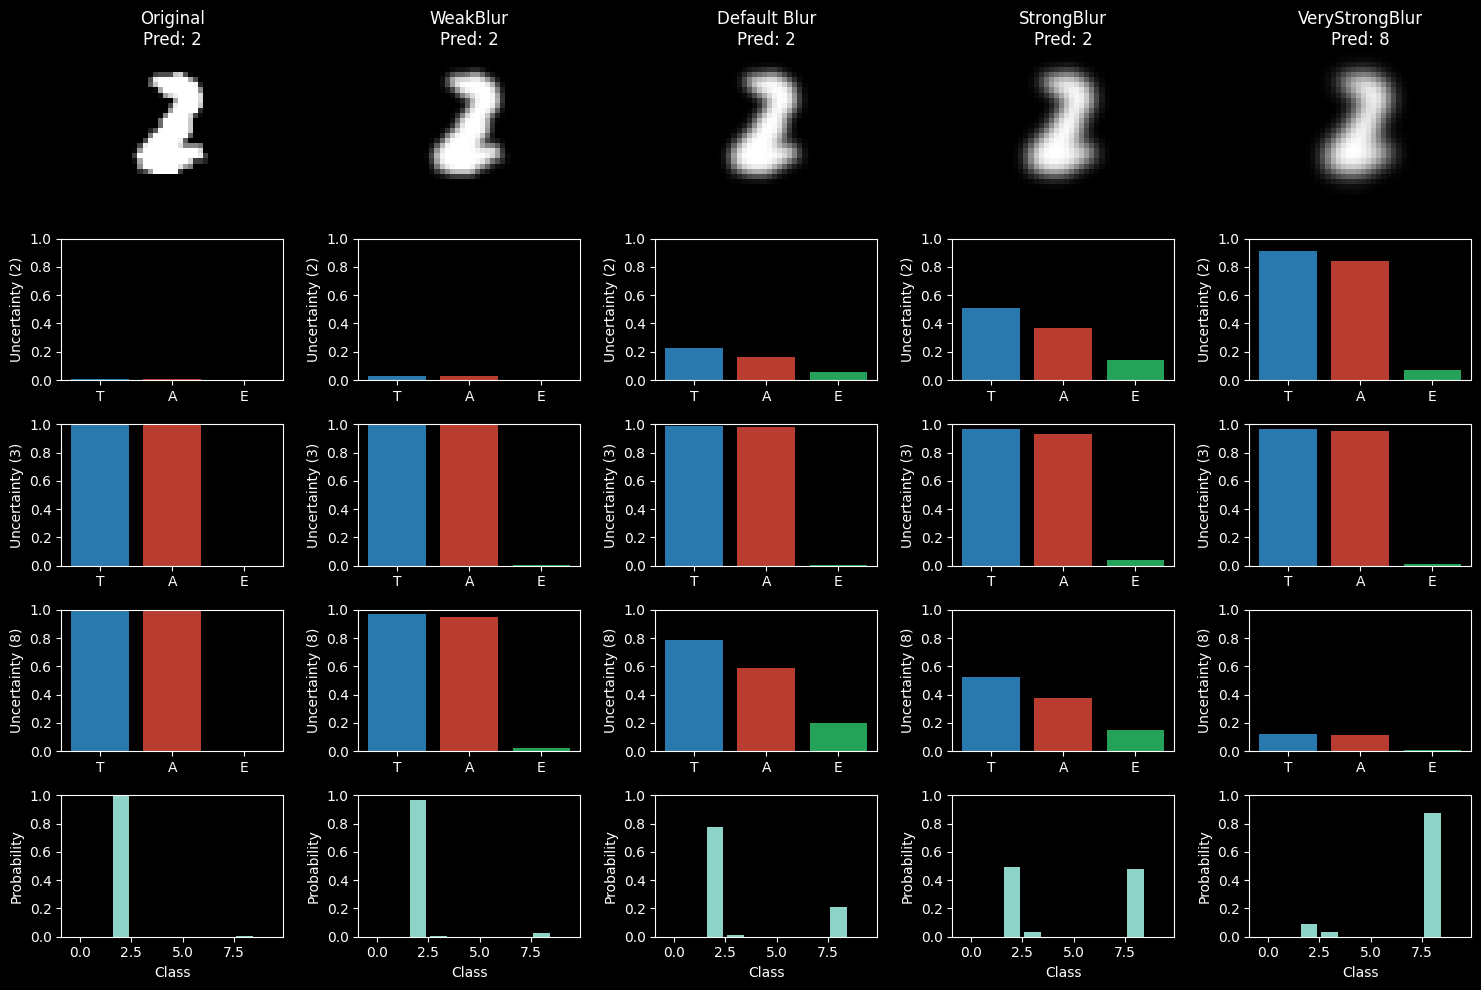

In [72]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

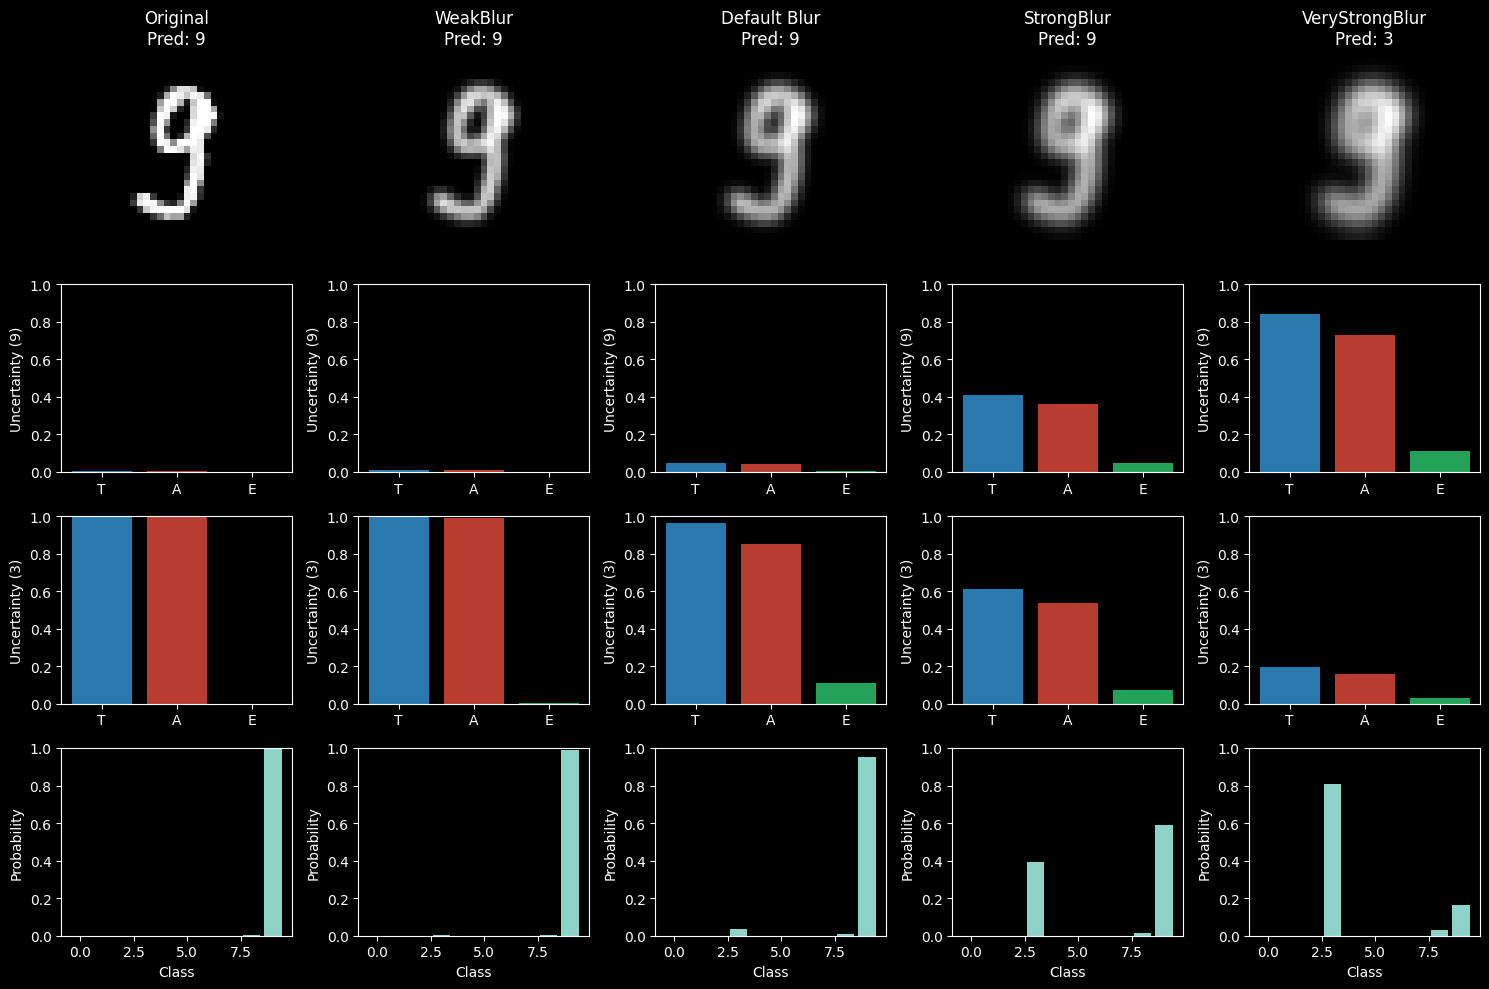

In [87]:
img, label = get_img_from_loader(test_loader, batch_idx=265, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3), T=10)

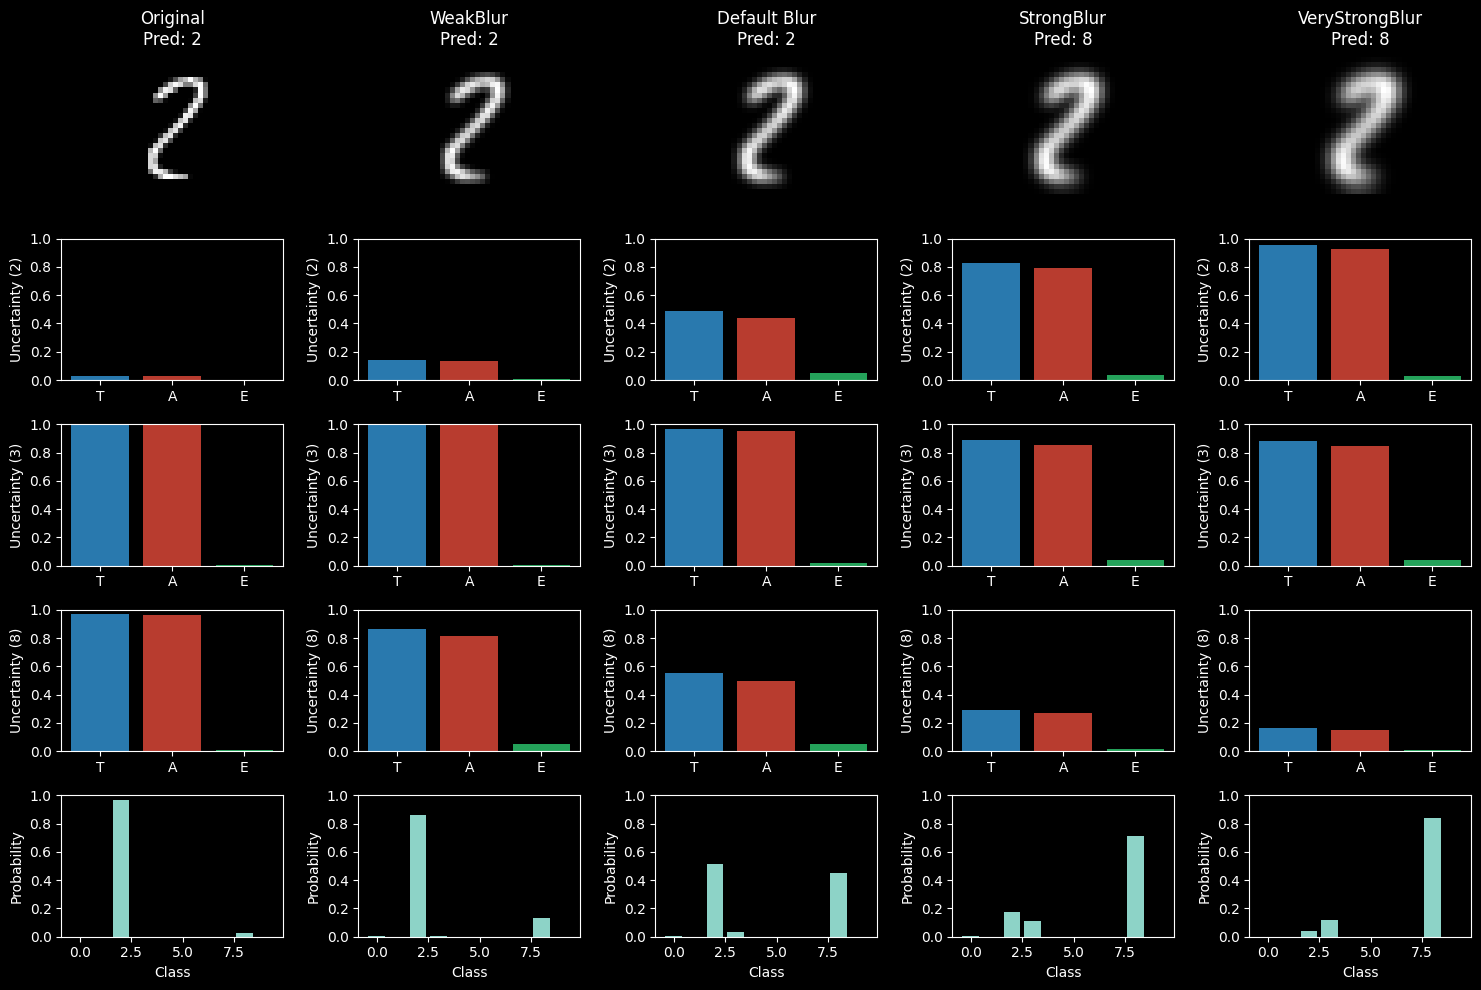

In [5]:
img, label = get_img_from_loader(test_loader, batch_idx=43, img_idx=11, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

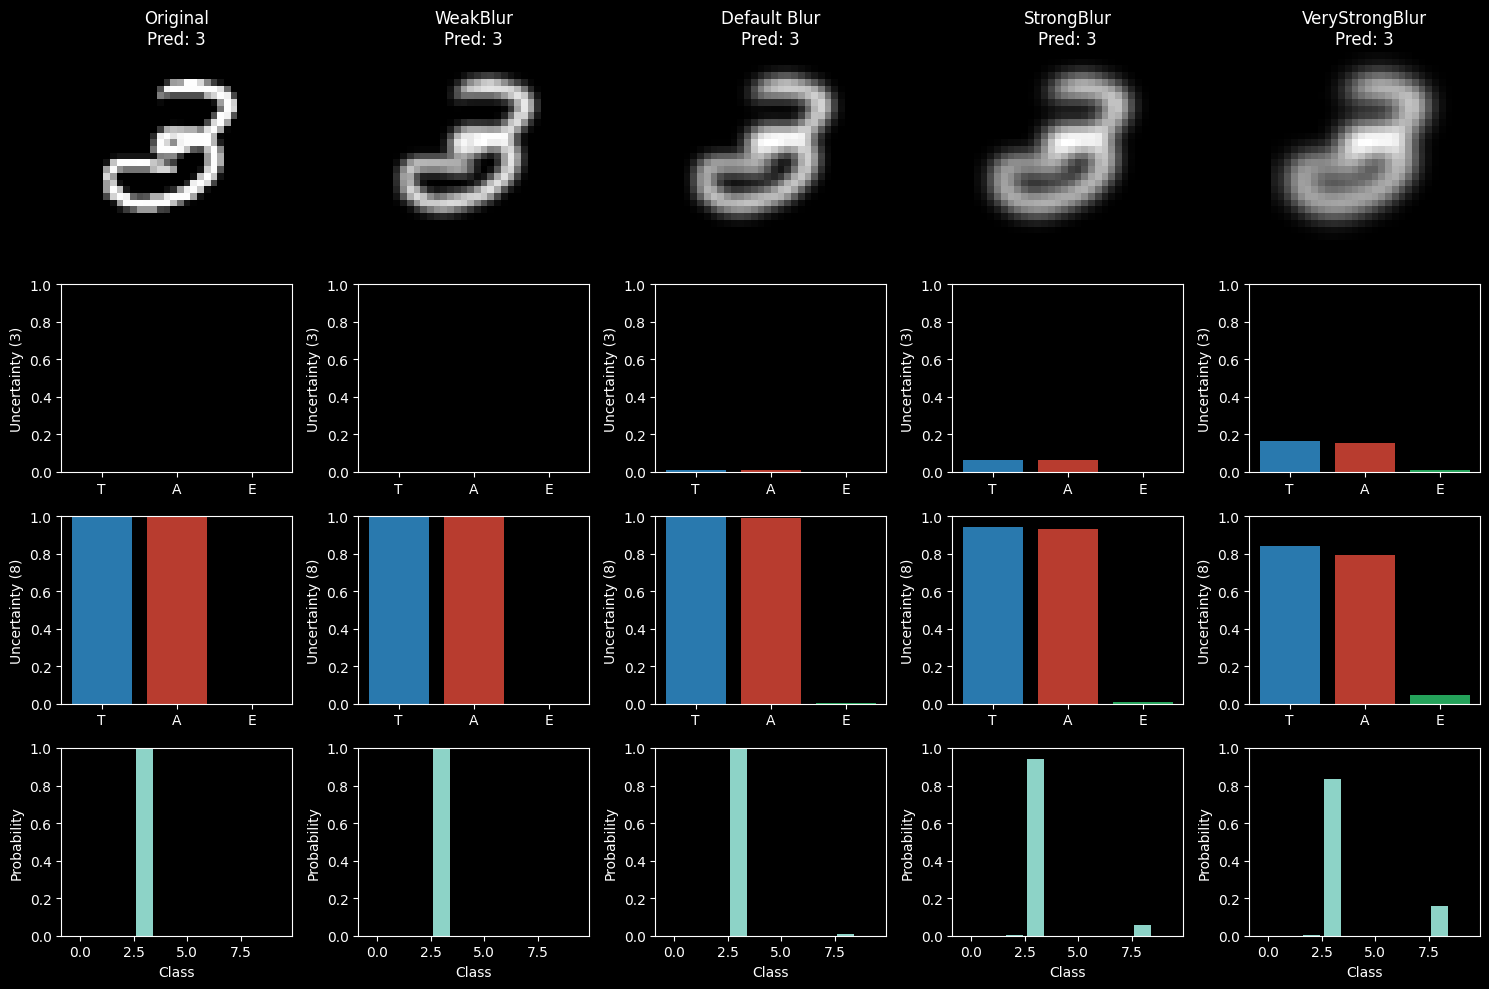

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=695, img_idx=12, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 8), T=10)

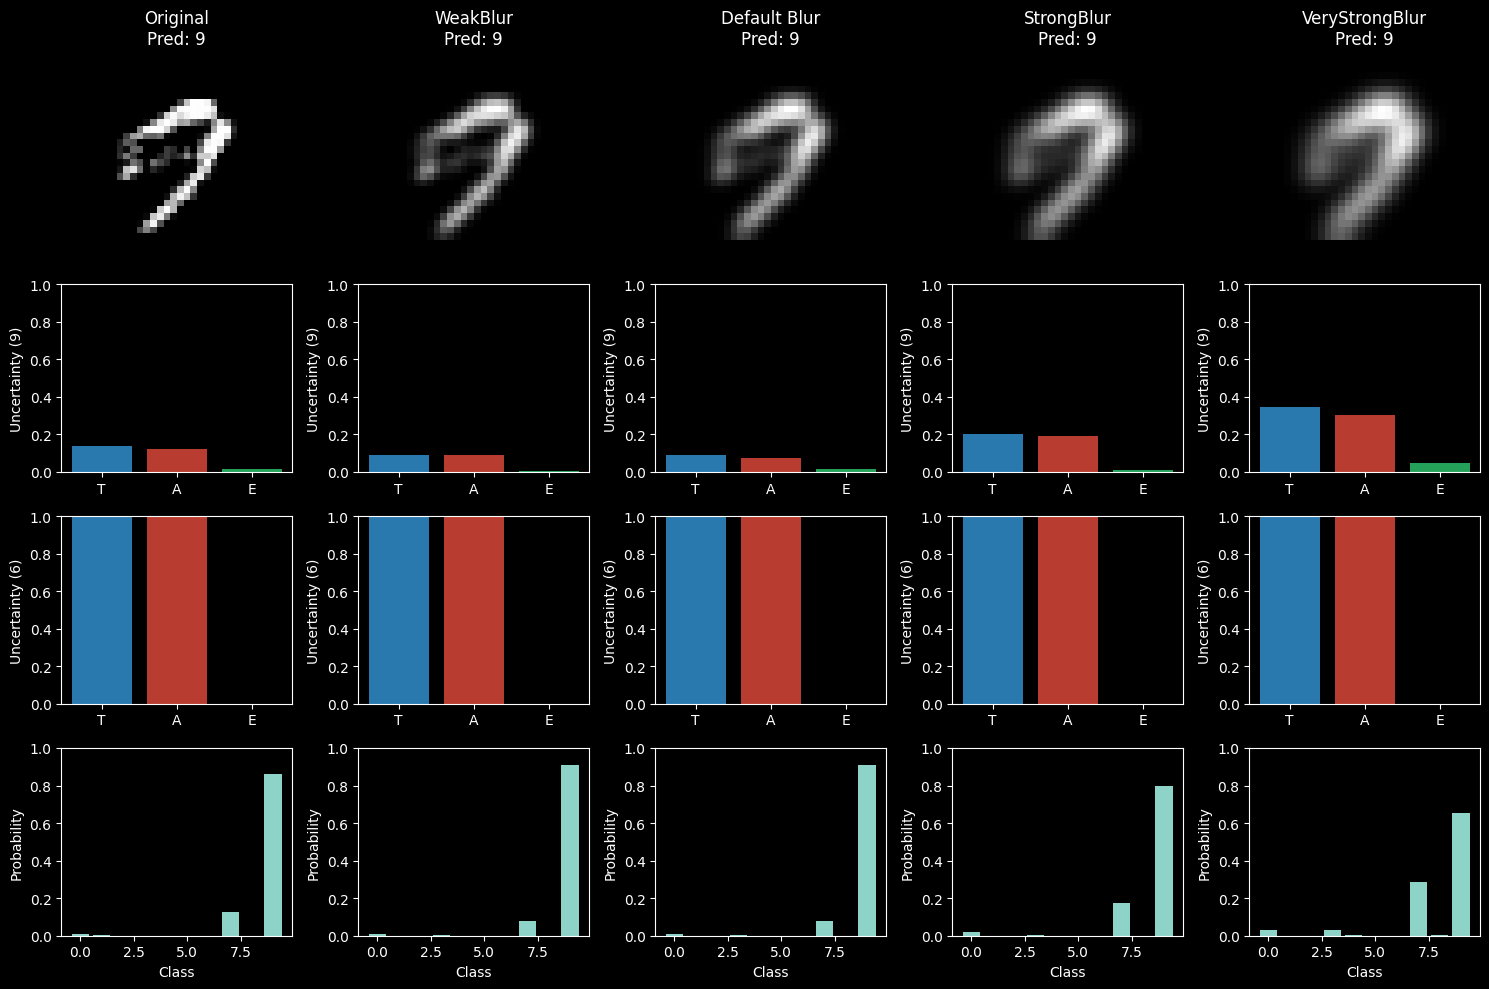

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=688, img_idx=10, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 6), T=10)